# Construction Safety Intelligence · Notebook 3: LLM versus classic NLP
**Author:** Atul Iwale · **Project 14** · Real OSHA data

Notebook 2 trained a logistic regression on 14,000 coded reports. An LLM needs no training data: it can be told the nine cause definitions and asked to code each report. Is it better, worse, or useful in a different way?

**How the LLM was run** (`src/llm_label.py`, `src/llm_prompt.py`): each of the 3,204 test narratives (2024 – Nov 2025) was sent to an OpenAI model **blind**, with the report ID and narrative only, never OSHA's code. Two versions:
- **Zero-shot:** instructions and the nine cause definitions only.
- **Few-shot:** the same, plus 10 worked examples taken from the *training* years (2015–2022).

The LLM also returned three things the classic model can't: the **fall height**, the **equipment** involved and the **task** being done.

**Contents**
1. Load and check the LLM answers · 2. Cause coding: LLM against OSHA and the classic model · 3. Where they disagree
4. Combining them: a review queue · 5. Fall height · 6. Equipment and task · 7. Cost and speed · 8. Export for the app

In [1]:
import json, re, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 140)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
PRICE_IN, PRICE_OUT = 0.10, 0.50   # USD per million tokens: gpt-6-luna list price from developers.openai.com/api/docs/models, checked Sep 2026

## 1. Load and check the LLM answers
Every answer was validated by the script: the cause must be one of the nine groups and the equipment one of the allowed values, or the request is retried.

In [2]:
lab = pd.read_csv('../data/test_labels_and_classic_predictions.csv', dtype={'report_id': str})
def load(mode):
    rows = [json.loads(l) for l in open(f'../data/llm_output_{mode}.jsonl') if l.strip()]
    df = pd.DataFrame(rows).drop_duplicates('report_id', keep='last')
    return df
llm = {m: load(m) for m in ['zero', 'few']}
for m, df in llm.items():
    ok = df[df.error.isna()]
    print(f"{m:5s}: {len(df):,} answers, {df.error.notna().sum()} failed, model {ok.model.mode()[0]}, "
          f"{ok.input_tokens.sum():,} input tokens, {ok.output_tokens.sum():,} output tokens, median {ok.seconds.median():.1f}s per call")
data = lab.copy()
for m, df in llm.items():
    df = df[df.error.isna()].set_index('report_id')
    for c in ['cause_group', 'fall_height_ft', 'equipment', 'task', 'confidence']:
        data[f'{m}_{c}'] = data.report_id.map(df[c])
missing = data[['zero_cause_group', 'few_cause_group']].isna().any(axis=1)
print(f'Reports with both LLM answers: {(~missing).sum():,} of {len(data):,}')
data = data[~missing].reset_index(drop=True)

zero : 3,204 answers, 0 failed, model gpt-6-luna, 2,274,994 input tokens, 415,580 output tokens, median 2.2s per call
few  : 3,204 answers, 0 failed, model gpt-6-luna, 5,350,834 input tokens, 374,228 output tokens, median 2.6s per call
Reports with both LLM answers: 3,204 of 3,204


## 2. Cause coding: LLM against OSHA and the classic model
All three are scored on exactly the same reports against OSHA's codes.

In [3]:
def row(pred): return {'accuracy': accuracy_score(data.cause_group, pred), 'macro-F1': f1_score(data.cause_group, pred, average='macro')}
comp = pd.DataFrame({'Logistic regression (trained on 14,000 reports)': row(data.model_pred),
                     'LLM zero-shot (no examples)': row(data.zero_cause_group),
                     'LLM few-shot (10 examples)': row(data.few_cause_group)}).T.round(3)
comp

,accuracy,macro-F1
"Logistic regression (trained on 14,000 reports)",0.838,0.832
LLM zero-shot (no examples),0.814,0.827
LLM few-shot (10 examples),0.816,0.826


In [4]:
CL = sorted(data.cause_group.unique())
per = pd.DataFrame({'Logistic regression': f1_score(data.cause_group, data.model_pred, average=None, labels=CL),
                    'LLM zero-shot': f1_score(data.cause_group, data.zero_cause_group, average=None, labels=CL),
                    'LLM few-shot': f1_score(data.cause_group, data.few_cause_group, average=None, labels=CL)}, index=CL)
per['support'] = data.cause_group.value_counts().reindex(CL)
per.round(3)

,Logistic regression,LLM zero-shot,LLM few-shot,support
Caught in or crushed,0.587,0.552,0.551,278
Electrical,0.976,0.951,0.951,186
Fall to lower level,0.941,0.950,0.952,1149
"Fire, explosion or burn",0.920,0.933,0.927,90
Heat stress,1.000,0.995,0.995,105
Other,0.763,0.847,0.830,73
"Slip, trip or same-level fall",0.763,0.796,0.794,167
Struck by or against object,0.778,0.730,0.734,884
Vehicle or mobile equipment,0.758,0.688,0.700,272


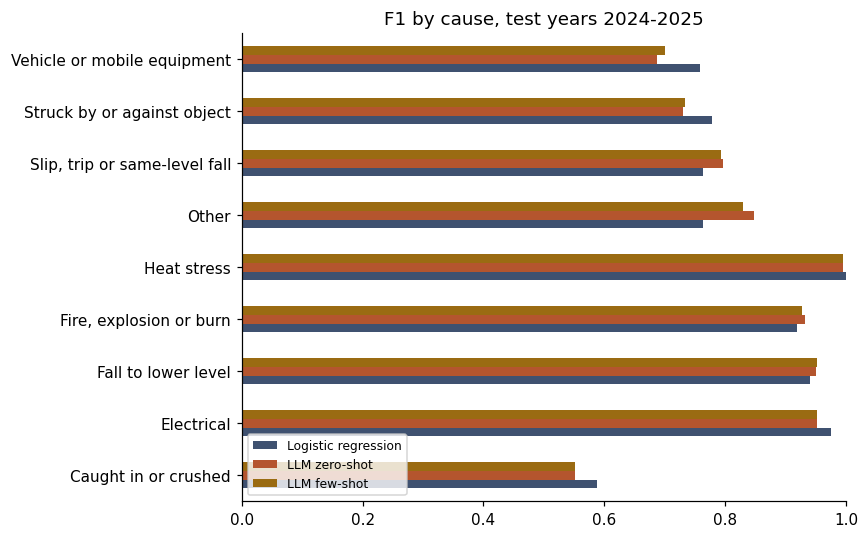

In [5]:
ax = per.drop(columns='support').plot.barh(figsize=(8, 5), color=['#3F5170', '#B4552E', '#9A6B12'])
ax.set_xlim(0, 1); ax.set_title('F1 by cause, test years 2024-2025'); ax.legend(loc='lower left', fontsize=8); plt.tight_layout(); plt.show()

## 3. Where they disagree

In [6]:
BEST = 'few' if comp.loc['LLM few-shot (10 examples)', 'macro-F1'] >= comp.loc['LLM zero-shot (no examples)', 'macro-F1'] else 'zero'
L = f'{BEST}_cause_group'
print(f'Using the {BEST}-shot LLM from here on.')
agree = data.model_pred == data[L]
print(f'Classic model and LLM agree on {agree.mean():.1%} of reports.')
dis = data[~agree]
print(f'Where they disagree ({len(dis)} reports): classic right {(dis.model_pred == dis.cause_group).mean():.1%}, LLM right {(dis[L] == dis.cause_group).mean():.1%}, neither {((dis.model_pred != dis.cause_group) & (dis[L] != dis.cause_group)).mean():.1%}')
print('\nMost common LLM confusions (OSHA -> LLM):')
print(data[data[L] != data.cause_group].groupby(['cause_group', L]).size().sort_values(ascending=False).head(6).to_string())

Using the zero-shot LLM from here on.
Classic model and LLM agree on 85.0% of reports.
Where they disagree (479 reports): classic right 53.2%, LLM right 37.6%, neither 9.2%

Most common LLM confusions (OSHA -> LLM):
cause_group                  zero_cause_group             
Struck by or against object  Caught in or crushed             292
Vehicle or mobile equipment  Caught in or crushed              47
                             Struck by or against object       44
Caught in or crushed         Struck by or against object       34
Vehicle or mobile equipment  Fall to lower level               26
Fall to lower level          Slip, trip or same-level fall     22


In [7]:
full = pd.read_csv('../data/osha_construction_clean.csv', dtype={'report_id': str}).set_index('report_id')
ex = data[(data[L] != data.cause_group)].head(5)
for _, r in ex.iterrows():
    print(f"OSHA: {r.cause_group} ({r.event_title}) | LLM: {r[L]} | classic: {r.model_pred}\n  {full.loc[r.report_id, 'narrative'][:260]}\n")

OSHA: Struck by or against object (Struck by other falling object n.e.c.) | LLM: Caught in or crushed | classic: Struck by or against object
  An employee was unloading concrete stumps for light poles off a forklift. One of the stumps slipped off the forks and the employee attempted to grab it when it crushed his left index fingertip, resulting in surgical amputation.

OSHA: Fall to lower level (Other fall to lower level unspecified) | LLM: Slip, trip or same-level fall | classic: Fall to lower level
  An employee fell while carrying a jackhammer down a hillside. The employee suffered fractures to three lower-back vertebrae and was hospitalized.

OSHA: Struck by or against object (Struck by running powered equipment during maintenance, cleaning, testing) | LLM: Caught in or crushed | classic: Caught in or crushed
  An employee was helping a mechanic troubleshoot a jammed ATV winch hook. The winch switch was jogged inside the cab. As the employee was pulling on the hook, it rolled into 

## 4. Combining them: a review queue
A safety team doesn't need one model to be right every time. It needs to know **which codings to trust and which to check**. When two very different methods, a word-weight model trained on OSHA's history and an LLM reading definitions, agree, the coding is much more likely to be right.

In [8]:
q = pd.DataFrame({
    'reports': [agree.sum(), (~agree).sum()],
    'share of reports': [agree.mean(), 1 - agree.mean()],
    'accuracy of the classic coding': [(data.model_pred == data.cause_group)[agree].mean(), (data.model_pred == data.cause_group)[~agree].mean()],
}, index=['Both agree: auto-code', 'They disagree: send to a person']).round(3)
q

,reports,share of reports,accuracy of the classic coding
Both agree: auto-code,2725,0.85,0.891
They disagree: send to a person,479,0.15,0.532


This is the practical design: auto-code the reports where both methods agree, and send the rest to a safety professional. The person reviews a small share of reports, and the auto-coded ones are far more accurate than either method alone.

## 5. Fall height
OSHA's title records a height band for some falls. Notebook 2's rule took the first height in the text. The LLM was asked for the height *of the fall*, not of the ladder or wall.

In [9]:
def band(ft):
    if ft is None or pd.isna(ft): return ''
    for lim, b in [(6, 'Under 6 ft'), (11, '6-10 ft'), (16, '11-15 ft'), (21, '16-20 ft'), (26, '21-25 ft'), (31, '26-30 ft')]:
        if ft < lim: return b
    return 'Over 30 ft'
f = data[(data.cause_group == 'Fall to lower level') & data.fall_band_osha.notna()].copy()
f['rule_band'] = f.rule_ft.map(band); f['llm_band'] = f[f'{BEST}_fall_height_ft'].map(band)
fh = pd.DataFrame({
    'height found': [(f.rule_band != '').mean(), (f.llm_band != '').mean()],
    'band matches OSHA (when found)': [(f.rule_band == f.fall_band_osha)[f.rule_band != ''].mean(), (f.llm_band == f.fall_band_osha)[f.llm_band != ''].mean()],
    'band matches OSHA (overall)': [(f.rule_band == f.fall_band_osha).mean(), (f.llm_band == f.fall_band_osha).mean()],
}, index=['Rule: first height in the text', 'LLM: height of the fall']).round(3)
print(f'{len(f)} test falls have a height band in OSHA\'s title'); fh

196 test falls have a height band in OSHA's title


,height found,band matches OSHA (when found),band matches OSHA (overall)
Rule: first height in the text,0.781,0.758,0.592
LLM: height of the fall,0.668,0.985,0.658


In [10]:
diff = f[(f.rule_band != f.fall_band_osha) & (f.llm_band == f.fall_band_osha)].head(4)
for _, r in diff.iterrows():
    print(f"OSHA band {r.fall_band_osha} | rule {r.rule_ft} ft | LLM {r[f'{BEST}_fall_height_ft']} ft\n  {full.loc[r.report_id, 'narrative'][:260]}\n")

OSHA band Under 6 ft | rule 6.0 ft | LLM 1.83 ft
  An employee was on a 6-foot ladder. Their foot was caught on the second rung causing the employee to fall approximately 22 inches and sustain a hip fracture.

OSHA band Under 6 ft | rule nan ft | LLM 3.0 ft
  An employee was climbing down from a top structure, which was sitting on structural steel horses. As the employee climbed down onto one of the horses, he slipped and fell, landing right-hand-first on the ground 36 inches below. His right wrist was broken.

OSHA band Under 6 ft | rule 8.0 ft | LLM 5.0 ft
  An employee was standing on an 8-foot ladder about halfway up the rungs (approximately 5 feet off the floor) to reach the ductwork to make the cut with a reciprocating saw. The unit snapped off and swung down, striking the large HVAC unit mounted to the concre

OSHA band Under 6 ft | rule 6.0 ft | LLM 4.0 ft
  An employee was standing on an six-foot A-frame ladder cutting a metal pipe using a battery operated saw. The saw blade g

## 6. Equipment and task
These fields are not in OSHA's codes at all, so there is no answer key. They are checked for plausibility and used for analysis the codes can't support.

In [11]:
E = f'{BEST}_equipment'
falls_all = data[data.cause_group == 'Fall to lower level']
eq = falls_all[E].value_counts().head(8).to_frame('falls')
eq['median fall height (ft)'] = falls_all.groupby(E)[f'{BEST}_fall_height_ft'].median().reindex(eq.index)
print('Falls to a lower level, 2024-2025, by equipment (LLM-extracted):'); eq

Falls to a lower level, 2024-2025, by equipment (LLM-extracted):


,falls,median fall height (ft)
zero_equipment,,
ladder,407,8.50
"structure, floor opening or edge",233,12.00
roof,193,16.00
scaffold,111,10.50
truck or other vehicle,45,4.50
aerial or scissor lift,45,16.00
none or unclear,26,18.75
crane or hoist,18,8.29


In [12]:
print('Equipment by cause (top 3 each):')
data.groupby('cause_group')[E].agg(lambda s: ', '.join(f'{k} ({v})' for k, v in s.value_counts().head(3).items()))

Equipment by cause (top 3 each):


cause_group
Caught in or crushed                                           none or unclear (62), power tool (48), excavator or earthmoving machine (36)
Electrical                       electrical equipment or power line (178), aerial or scissor lift (5), excavator or earthmoving machine (1)
Fall to lower level                                                        ladder (407), structure, floor opening or edge (233), roof (193)
Fire, explosion or burn                                                     none or unclear (39), welding or hot work (19), power tool (11)
Heat stress                                                                       none or unclear (71), roof (16), trench or excavation (5)
Other                                                                      none or unclear (45), truck or other vehicle (8), power tool (7)
Slip, trip or same-level fall                      none or unclear (89), structure, floor opening or edge (32), truck or other vehicle (12)
Struck b

In [13]:
print('Random sample of extractions, for a plausibility check:')
s = data.sample(6, random_state=3)
for _, r in s.iterrows():
    print(f"[{r[L]} | {r[E]} | task: {r[f'{BEST}_task']} | height: {r[f'{BEST}_fall_height_ft']}]\n  {full.loc[r.report_id, 'narrative'][:220]}\n")

Random sample of extractions, for a plausibility check:
[Fall to lower level | ladder | task: Climbing a ladder | height: nan]
  An employee was climbing a ladder when they fell to the ground and sustained a broken arm.

[Heat stress | none or unclear | task: Working outside on bridge construction | height: nan]
  An employee was working outside on a bridge construction project on a hot day when they began feeling ill. The employee was hospitalized with heat exhaustion.

[Struck by or against object | power tool | task: Driving steel H-beams into the ground | height: nan]
  An employee was driving steel H-beams into the ground using a diesel-powered driving hammer when a piston broke in half and came down on their right hand, resulting in a compound fracture to their hand and wrist.

[Struck by or against object | trench or excavation | task: Setting a water pump to dewater trench | height: nan]
  An employee was setting a water pump to dewater in a small trench when a piece of clay br

## 7. Cost and speed

In [14]:
cost = {}
for m, df in llm.items():
    ok = df[df.error.isna()]
    usd = ok.input_tokens.sum() / 1e6 * PRICE_IN + ok.output_tokens.sum() / 1e6 * PRICE_OUT
    cost[f'LLM {m}-shot'] = {'input tokens per report': ok.input_tokens.mean(), 'estimated cost (USD) for 3,204 reports': usd,
                             'USD per 1,000 reports': usd / len(ok) * 1000, 'median seconds per report': ok.seconds.median()}
cost['Logistic regression'] = {'input tokens per report': 0, 'estimated cost (USD) for 3,204 reports': 0, 'USD per 1,000 reports': 0, 'median seconds per report': 0.0001}
pd.DataFrame(cost).T.round(4)

,input tokens per report,"estimated cost (USD) for 3,204 reports","USD per 1,000 reports",median seconds per report
LLM zero-shot,710.0481,0.4353,0.1359,2.2400
LLM few-shot,1670.0481,0.7222,0.2254,2.6200
Logistic regression,0.0000,0.0000,0.0000,0.0001


Cost is estimated from the token counts the API returned and the model's published price (noted at the top of this notebook); the exact bill is on the OpenAI usage page.

## 8. Export for the app

In [15]:
cz, cf, cl = [comp.loc[i] for i in ['LLM zero-shot (no examples)', 'LLM few-shot (10 examples)', 'Logistic regression (trained on 14,000 reports)']]
summary = {
    'lead': (f"The same {len(data):,} test reports, coded blind by an OpenAI model ({llm[BEST][llm[BEST].error.isna()].model.mode()[0]}) from the nine cause definitions. "
             f"Where the LLM and the classic model agree ({agree.mean():.0%} of reports), the coding matches OSHA {q.iloc[0, 2]:.0%} of the time, "
             f"so a person only needs to review the {1 - agree.mean():.0%} where they disagree."),
    'columns': ['Method', 'Accuracy', 'Macro-F1', 'Training data needed', 'Cost per 1,000 reports'],
    'rows': [
        ['Logistic regression (in this app)', f"{cl['accuracy']:.1%}", f"{cl['macro-F1']:.3f}", '14,000 coded reports', 'free'],
        ['LLM zero-shot', f"{cz['accuracy']:.1%}", f"{cz['macro-F1']:.3f}", 'none, definitions only', f"${cost['LLM zero-shot']['USD per 1,000 reports']:.2f}"],
        ['LLM few-shot', f"{cf['accuracy']:.1%}", f"{cf['macro-F1']:.3f}", '10 examples', f"${cost['LLM few-shot']['USD per 1,000 reports']:.2f}"],
        ['Both agree → auto-code', f"{q.iloc[0, 2]:.1%}", '', f'covers {agree.mean():.0%} of reports', ''],
    ],
    'fall_height': fh.round(3).reset_index().rename(columns={'index': 'method'}).to_dict(orient='records'),
}
with open('../model/llm_summary.json', 'w') as fo: json.dump(summary, fo, indent=1)
print(json.dumps(summary, indent=1)[:1500])

{
 "lead": "The same 3,204 test reports, coded blind by an OpenAI model (gpt-6-luna) from the nine cause definitions. Where the LLM and the classic model agree (85% of reports), the coding matches OSHA 89% of the time, so a person only needs to review the 15% where they disagree.",
 "columns": [
  "Method",
  "Accuracy",
  "Macro-F1",
  "Training data needed",
  "Cost per 1,000 reports"
 ],
 "rows": [
  [
   "Logistic regression (in this app)",
   "83.8%",
   "0.832",
   "14,000 coded reports",
   "free"
  ],
  [
   "LLM zero-shot",
   "81.4%",
   "0.827",
   "none, definitions only",
   "$0.14"
  ],
  [
   "LLM few-shot",
   "81.6%",
   "0.826",
   "10 examples",
   "$0.23"
  ],
  [
   "Both agree \u2192 auto-code",
   "89.1%",
   "",
   "covers 85% of reports",
   ""
  ]
 ],
 "fall_height": [
  {
   "method": "Rule: first height in the text",
   "height found": 0.781,
   "band matches OSHA (when found)": 0.758,
   "band matches OSHA (overall)": 0.592
  },
  {
   "method": "LLM: heigh

## Summary
- **With no training data, the LLM comes close to the trained model.** Zero-shot, from definitions alone, it agrees with OSHA's coders on 81.4% of 2024–2025 reports (macro-F1 0.827), against 83.8% (0.832) for the logistic regression trained on 14,000 coded reports. Ten examples (few-shot) barely changed the result.
- **They are good at different things.** The LLM is better on falls, slips, fire and "Other" (bites, chemicals, violence), where understanding the sentence helps. It is worse on struck-by and vehicles: it often calls a crushed finger "caught in" when OSHA's new manual says "struck by". It follows the plain meaning of the definitions, not OSHA's coding conventions, which the trained model learned from history.
- **Together they make a practical workflow.** The two agree on 85% of reports, and those codings match OSHA 89% of the time. Only the 15% where they disagree need a person, and on those the trained model is right about half the time.
- **Fall height is where the LLM clearly wins.** When it gives a height, its band matches OSHA's in 98.5% of cases, against 75.8% for the "first height in the text" rule, because it separates the fall height from the ladder or wall height ("a 6-foot ladder… fell about four feet"). It is more cautious, giving a height for 67% of falls against 78% for the rule.
- **Cost:** about $0.14 per 1,000 reports zero-shot and $0.23 few-shot (estimated from token counts at the model's list price), at about 2 seconds per report. The trained model is free and instant, so it stays the default, with the LLM as a second opinion and for extracting details the codes don't hold.